# Image Classification with EXECUTORCH

This notebook demonstrates image classification using PyTorch EXECUTORCH on edge devices (Raspberry Pi).

**Author:** Prof. Marcelo Rovai (UNIFEI)

**Prerequisites:**
- Raspberry Pi 4 or 5 with camera module (we will use the Raspberry Pi 5)
- Python 3.9+ (We are using Python 3.11)
- Virtual environment with PyTorch and EXECUTORCH installed

---

## 1. Setup and Verification

In [20]:
# Import required libraries
import os
import time
import json
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import transforms
import executorch
from executorch.extension.pybindings.portable_lib import _load_for_executorch

print("=" * 50)
print("SETUP VERIFICATION")
print("=" * 50)

# Check versions
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"PIL version: {Image.__version__}")
print(f"EXECUTORCH available: {executorch is not None}")

# Test basic PyTorch functionality
x = torch.randn(3, 224, 224)
print(f"\nCreated test tensor with shape: {x.shape}")

# Test PIL
test_img = Image.new('RGB', (224, 224), color='red')
print(f"Created test PIL image: {test_img.size}")

print("\n✓ Setup verification complete!")
print("=" * 50)

SETUP VERIFICATION
PyTorch version: 2.9.1+cpu
NumPy version: 2.2.6
PIL version: 12.1.0
EXECUTORCH available: True

Created test tensor with shape: torch.Size([3, 224, 224])
Created test PIL image: (224, 224)

✓ Setup verification complete!


## 2. Download Test Image

- Download test image for example from:
    - "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"
    - And save it on the ../images folder as "cat.jpg"

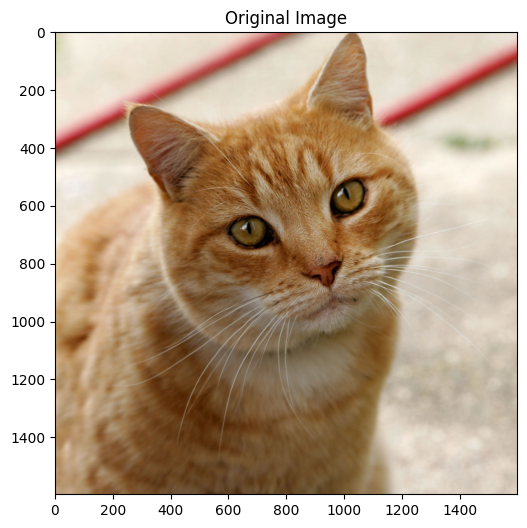

Image size: (1600, 1598)
Image mode: RGB


In [9]:
img_path = "../images/cat.jpg"

# Load and display
img = Image.open(img_path)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Original Image")
#plt.axis('off')
plt.show()

print(f"Image size: {img.size}")
print(f"Image mode: {img.mode}")

## 3. Load EXECUTORCH Model

**Note:** You need to export a model first using the `export_mobv2_executorch.py` script.

If you don't have a model yet, run the export script first:
 - `python export_mobv2_executorch.py`

In [12]:
ls ../models

imagenet_labels.json  mobilenet_v2_quantized_xnnpack.pte
mobilenet_v2.pte      mobilenet_v2_xnnpack.pte
mobilenet_v2.pth


In [16]:
# Load the EXECUTORCH model
model_path = "../models/mobilenet_v2.pte"

try:
    model = _load_for_executorch(model_path)
    print(f"Model loaded successfully from: {model_path}")
    #print(f"  Available methods: {model.method_names}")
    
    # Check file size
    file_size = os.path.getsize(model_path) / (1024 * 1024)  # MB
    print(f"Model size: {file_size:.2f} MB")
    
except FileNotFoundError:
    print(f"✗ Model not found: {model_path}")
    print("\nPlease run the export script first:")
    print("  python export_mobilenet.py")

Model loaded successfully from: ../models/mobilenet_v2.pte
Model size: 13.58 MB


## 4. Download ImageNet Labels

In [29]:
# Download and save ImageNet labels (if you do not have it)
LABELS_PATH = "../models/imagenet_labels.json"

if not os.path.exists(LABELS_PATH):
    print("Downloading ImageNet labels...")
    LABELS_URL = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
    with urllib.request.urlopen(LABELS_URL) as url:
        labels = json.load(url)
    
    # Save labels locally
    with open(LABELS_PATH, 'w') as f:
        json.dump(labels, f)
    print(f"Labels saved to {LABELS_PATH}")
else:
    print("Loading labels from disk...")
    with open(LABELS_PATH, 'r') as f:
        labels = json.load(f)      

Loading labels from disk...


In [30]:
print(f"\nTotal classes: {len(labels)}")
print(f"Sample labels: {labels[280:285]}")  


Total classes: 1000
Sample labels: ['grey fox', 'tabby cat', 'tiger cat', 'Persian cat', 'Siamese cat']


## 5. Image Preprocessing

A preprocessing pipeline is needed because ExecuTorch only runs the exported core network; it does not include the input normalization logic that MobileNet v2 expects, and the model will give incorrect predictions if the input tensor is not in the exact format it was trained on.

What MobileNet v2 expects
For typical PyTorch MobileNet v2 models (ImageNet‑pretrained):
	•	Input shape: 3‑channel RGB tensor of size.
	•	Value range: floating-point values, usually in float32 after dividing by 255.
	•	Normalization: per‑channel mean/std (ImageNet) normalization, e.g., `mean=0.485, 0.456, 0.406`, `std=0.229, 0.224, 0.225`.

These steps (resize, convert to tensor, normalize) are not “optional decorations”; they are part of the functional definition of the model’s expected input distribution.

### Define preprocessing pipeline

In [31]:
preprocess = transforms.Compose([
    transforms.Resize(256),              # Resize to 256
    transforms.CenterCrop(224),          # Center crop to 224x224
    transforms.ToTensor(),               # Convert to tensor [0, 1]
    transforms.Normalize(                # Normalize with ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

### Apply preprocessing

In [35]:
input_tensor = preprocess(img)
print(f"  Input shape: {input_tensor.shape}")
print(f"  Input dtype: {input_tensor.dtype}")

  Input shape: torch.Size([3, 224, 224])
  Input dtype: torch.float32


### Add batch dimension: [1, 3, 224, 224]

In [37]:
input_batch = input_tensor.unsqueeze(0)  

print(f"  Input shape: {input_batch.shape}")
print(f"  Input dtype: {input_batch.dtype}")
print(f"  Value range: [{input_batch.min():.3f}, {input_batch.max():.3f}]")

  Input shape: torch.Size([1, 3, 224, 224])
  Input dtype: torch.float32
  Value range: [-2.084, 2.309]


The Preprocessing is complete!

## 6. Run Inference

For inference, we should run a forward pass of the model in inference mode (`torch.no_grad()`), measure the time, and print basic information about the outputs.

`torch.no_grad()` is a context manager that disables gradient calculation inside its block. During inference, we do not need gradients, so disabling them:
- Saves memory (no computation graph is stored).
- Can speed up computation slightly.
- Everything computed inside this block will have `requires_grad=False`, so we cannot call `.backward()` on it.

In [42]:
# Run inference
with torch.no_grad():
    start_time = time.time()
    outputs = model.forward((input_batch,))
    inference_time = time.time() - start_time

print(f"Inference completed in {inference_time*1000:.2f} ms")
print(f"Output type: {type(outputs)}")
print(f"Output shape: {outputs[0].shape}")

Inference completed in 2478.74 ms
Output type: <class 'list'>
Output shape: torch.Size([1, 1000])


`type(outputs)` tells us what container the model returned. Often this is a tuple or list when working with exported/ExecuTorch‑style models, e.g. `<class 'tuple'>`.

That container may hold one or more tensors (e.g., logits, auxiliary outputs). 
- `outputs[0]` accesses the first element of that container (usually the main output tensor), and `.shape` prints its dimensions (For image classification, this is often `batch_size, num_classes`). 

## 7. Process and Display Results

Now we should take the model’s raw scores (logits) for a single image, convert them into probabilities with softmax, select the top‑5 most likely classes, and print them nicely formatted.
- `outputs[0][0]` selects the first element in the batch, giving a 1D tensor of logits of length `num_classes`.
- `torch.nn.functional.softmax(..., dim=0)` applies the softmax function along that 1D dimension, turning logits into probabilities that sum to 1.

In [9]:
# Apply softmax to get probabilities
probabilities = torch.nn.functional.softmax(outputs[0][0], dim=0)

# Get top 5 predictions
top5_prob, top5_indices = torch.topk(probabilities, 5)

# Display results
print("\n" + "="*60)
print("TOP 5 PREDICTIONS")
print("="*60)
print(f"{'Class':<35} {'Probability':>10}")
print("-"*60)

for i in range(5):
    label = labels[top5_indices[i]]
    prob = top5_prob[i].item() * 100
    print(f"{label:<35} {prob:>9.2f}%")

print("="*60)


TOP 5 PREDICTIONS
Class                               Probability
------------------------------------------------------------
tiger cat                               12.85%
Egyptian cat                             9.75%
tabby                                    6.09%
lynx                                     1.70%
carton                                   0.84%


## 8. Create Reusable Classification Function

For simplicity and reuse across other tests, let's create a reusable function that builds on what was done so far. 

In [60]:
def classify_image_executorch(img_path, model_path, labels_path, top_k=5, show_image=True):
    """
    Classify an image using EXECUTORCH model
    
    Args:
        img_path: Path to input image
        model_path: Path to .pte model file
        labels_path: Path to labels text file
        top_k: Number of top predictions to return
        show_image: Whether to display the image
    
    Returns:
        inference_time: Inference time in ms
        top_indices: Indices of top k predictions
        top_probs: Probabilities of top k predictions
    """
    # Load image
    img = Image.open(img_path).convert('RGB')
    
    # Display image
    if show_image:
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title('Input Image')
        plt.show()

    print(f"Image Path: {img_path}")
    
    # Load model
    print(f"Model Path {model_path}") 
    model_size = os.path.getsize(model_path) / (1024 * 1024)
    print(f"Model size: {model_size:6.2f} MB")
    
    model = _load_for_executorch(model_path)

    # Preprocess
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])
    
    input_tensor = preprocess(img)
    input_batch = input_tensor.unsqueeze(0)
    
    # Inference
    with torch.no_grad():
        start_time = time.time()
        outputs = model.forward((input_batch,))
        inference_time = (time.time() - start_time)*1000
        
    
    # Process results
    probabilities = torch.nn.functional.softmax(outputs[0][0], dim=0)
    top_prob, top_indices = torch.topk(probabilities, top_k)
    
    # Load labels
    with open(labels_path, 'r') as f:
        labels = json.load(f)
    
    # Display results
    print(f"\nInference time: {inference_time:.2f} ms")
    print("\n" + "="*60)
    print(f"{'[PREDICTION]':<35} {'[Probability]':>15}")
    print("-"*60)
    
    for i in range(top_k):
        label = labels[top_indices[i]]
        prob = top_prob[i].item() * 100
        print(f"{label:<35} {prob:>14.2f}%")
    
    print("="*60)
    
    return inference_time, top_indices, top_prob

print("✓ Classification function defined!")

✓ Classification function defined!


## 9. Test the Classification Function

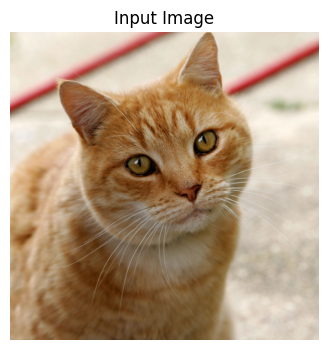

Image Path: ../images/cat.jpg
Model Path ../models/mobilenet_v2.pte
Model size:  13.58 MB

Inference time: 2445.20 ms

[PREDICTION]                          [Probability]
------------------------------------------------------------
tiger cat                                    47.44%
Egyptian Mau                                 37.61%
lynx                                          6.91%
tabby cat                                     6.22%
plastic bag                                   0.47%


In [61]:
# Test with the cat image
inf_time, indices, probs = classify_image_executorch(
    img_path="../images/cat.jpg",
    model_path="../models/mobilenet_v2.pte",
    labels_path="../models/imagenet_labels.json",
    top_k=5
)

In [62]:
inf_time, indices, probs

(2445.200204849243,
 tensor([282, 285, 287, 281, 728]),
 tensor([0.4744, 0.3761, 0.0691, 0.0622, 0.0047]))

## 10. Using the XNNPACK accelerated backend

Note: You need to export a model first using the `convert_mobv2_xnnpack.py` script.

If you don't have a model yet, run the export script first:

`python convert_mobv2_xnnpack.py`

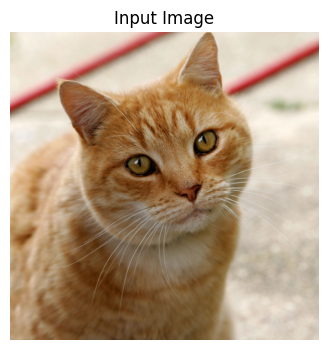

Image Path: ../images/cat.jpg
Model Path ../models/mobilenet_v2_xnnpack.pte
Model size:  13.35 MB

Inference time: 20.10 ms

[PREDICTION]                          [Probability]
------------------------------------------------------------
tiger cat                                    47.44%
Egyptian Mau                                 37.61%
lynx                                          6.91%
tabby cat                                     6.22%
plastic bag                                   0.47%


In [63]:
# Test with the cat image
inf_time, indices, probs = classify_image_executorch(
    img_path="../images/cat.jpg",
    model_path="../models/mobilenet_v2_xnnpack.pte",
    labels_path="../models/imagenet_labels.json",
    top_k=5
)

`The inference time was reduced from +2.5s to around -20ms`

## 11. Using a quantized model with the XNNPACK accelerated backend

Note: You need to export a model first using the ``convert_mobv2_xnnpack_int8.py`` script.

If you don't have a model yet, run the export script first:

`python convert_mobv2_xnnpack_int8.py` 

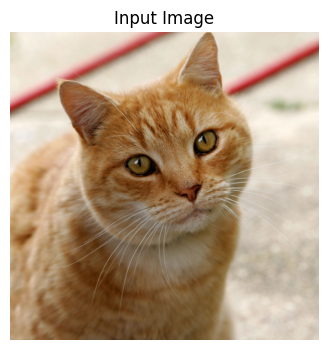

Image Path: ../images/cat.jpg
Model Path ../models/mobilenet_v2_quantized_xnnpack.pte
Model size:   3.59 MB

Inference time: 16.32 ms

[PREDICTION]                          [Probability]
------------------------------------------------------------
tiger cat                                    51.01%
Egyptian Mau                                 34.11%
lynx                                          7.54%
tabby cat                                     6.17%
plastic bag                                   0.37%


In [64]:
# Test with the cat image
inf_time, indices, probs = classify_image_executorch(
    img_path="../images/cat.jpg",
    model_path="../models/mobilenet_v2_quantized_xnnpack.pte",
    labels_path="../models/imagenet_labels.json",
    top_k=5
)

`==> Even faster inference with a lower model in size`

`Slightly higher probabilities in the INT8 model are normal and do not indicate a problem by themselves. Quantization slightly changes the logits, and softmax can become a bit “sharper” or “flatter” even when top‑1 remains correct.`

## 11. Camera Integration

We essentially have two different Python worlds: system Python 3.13 (where the camera stack is wired up) and our 3.11 virtual env (where ExecuTorch is installed). To run ExecuTorch on live frames from the Pi camera, we need to bridge those worlds.

Why the camera “only works” in 3.13
- Recent Raspberry Pi OS uses Picamera2 on top of libcamera as the recommended interface.
- The Picamera2/libcamera Python bindings are usually installed into the system Python and are not trivially pip‑installable into arbitrary venvs or other Python versions.
- Once we create a separate 3.11 environment, it will not automatically see the Picamera2/libcamera bindings that live under 3.13, so imports fail, or the camera device is not accessible from that environment.

> We will use a `two‑process solution`: capture in 3.13, infer in 3.11. 

For that, we should run a small capture service under Python 3.13 that:
- Grabs frames from the Pi camera (Picamera2 / libcamera).
- Sends frames to your ExecuTorch process (3.11) over a local channel (e.g., ZeroMQ, TCP/UDP socket, shared memory, filesystem (write JPEG/PNG to a temp directory and signal), or a simple HTTP server.
	
The 3.11 process (under venev) receives the frame, decodes it, runs the preprocessing pipeline (resize, normalize), then calls ExecuTorch for inference.. 

### Image Capture

Outside of the ExecuTorch env., we will create a folder (`CAMERA`). There we will run the script (`camera_capture.py`):

Runing the script, we um get an image that will be stored on:
- `/home/mjrovai/Documents/CAMERA/camera_capture.jpg`

In [79]:
ls ../../../../CAMERA

camera_capture.jpg  camera_capture.py


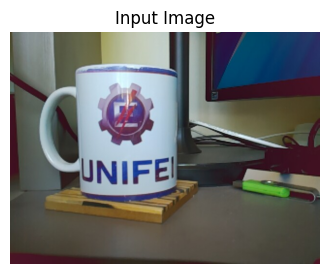

Image Path: ../../../../CAMERA/camera_capture.jpg
Model Path ../models/mobilenet_v2_quantized_xnnpack.pte
Model size:   3.59 MB

Inference time: 17.33 ms

[PREDICTION]                          [Probability]
------------------------------------------------------------
coffee mug                                   84.17%
oil filter                                    3.72%
punching bag                                  3.05%
candle                                        1.51%
bucket                                        1.23%


In [80]:
# Test the quantized model with the captured image
inf_time, indices, probs = classify_image_executorch(
    img_path="../../../../CAMERA/camera_capture.jpg",
    model_path="../models/mobilenet_v2_quantized_xnnpack.pte",
    labels_path="../models/imagenet_labels.json",
    top_k=5
)

## 12. Performance Benchmarking

In [65]:
def benchmark_inference(model_path, num_runs=50):
    """
    Benchmark model inference speed
    """
    print(f"Benchmarking model: {model_path}")
    print(f"Number of runs: {num_runs}\n")
    
    # Load model
    model = _load_for_executorch(model_path)
    
    # Create dummy input
    dummy_input = torch.randn(1, 3, 224, 224)
    
    # Warmup (10 runs)
    print("Warming up...")
    for _ in range(10):
        with torch.no_grad():
            _ = model.forward((dummy_input,))
    
    # Benchmark
    print(f"Running benchmark...")
    times = []
    for i in range(num_runs):
        start = time.time()
        with torch.no_grad():
            _ = model.forward((dummy_input,))
        times.append(time.time() - start)
    
    times = np.array(times) * 1000  # Convert to ms
    
    # Print statistics
    print("\n" + "="*50)
    print("BENCHMARK RESULTS")
    print("="*50)
    print(f"  Mean:   {times.mean():.2f} ms")
    print(f"  Median: {np.median(times):.2f} ms")
    print(f"  Std:    {times.std():.2f} ms")
    print(f"  Min:    {times.min():.2f} ms")
    print(f"  Max:    {times.max():.2f} ms")
    print("="*50)
    
    # Plot distribution
    plt.figure(figsize=(12, 4))
    
    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(times, bins=20, edgecolor='black', alpha=0.7)
    plt.axvline(times.mean(), color='red', linestyle='--', 
                label=f'Mean: {times.mean():.2f} ms')
    plt.xlabel('Inference Time (ms)')
    plt.ylabel('Frequency')
    plt.title('Inference Time Distribution')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Time series
    plt.subplot(1, 2, 2)
    plt.plot(times, marker='o', markersize=3, alpha=0.6)
    plt.axhline(times.mean(), color='red', linestyle='--', 
                label=f'Mean: {times.mean():.2f} ms')
    plt.xlabel('Run Number')
    plt.ylabel('Inference Time (ms)')
    plt.title('Inference Time Over Runs')
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return times

In [66]:
ls ../models

imagenet_labels.json  mobilenet_v2_quantized_xnnpack.pte
mobilenet_v2.pte      mobilenet_v2_xnnpack.pte
mobilenet_v2.pth


### mobilenet_v2.pte

Benchmarking model: ../models/mobilenet_v2.pte
Number of runs: 50

Warming up...
Running benchmark...

BENCHMARK RESULTS
  Mean:   2439.89 ms
  Median: 2439.84 ms
  Std:    2.17 ms
  Min:    2435.94 ms
  Max:    2444.99 ms


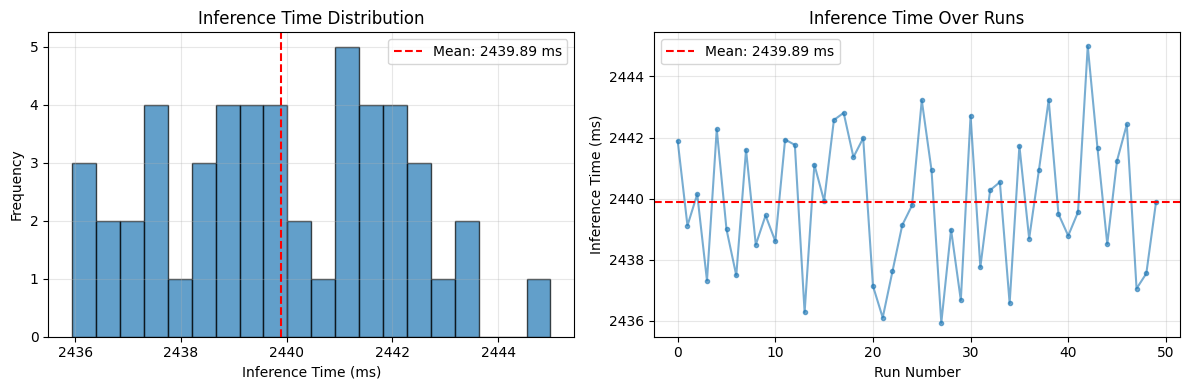

In [69]:
# Run benchmark
benchmark_times = benchmark_inference(
    model_path="../models/mobilenet_v2.pte",
    num_runs=50
)

### mobilenet_v2_xnnpack.pte

Benchmarking model: ../models/mobilenet_v2_xnnpack.pte
Number of runs: 50

Warming up...
Running benchmark...

BENCHMARK RESULTS
  Mean:   11.24 ms
  Median: 10.84 ms
  Std:    1.67 ms
  Min:    10.33 ms
  Max:    21.62 ms


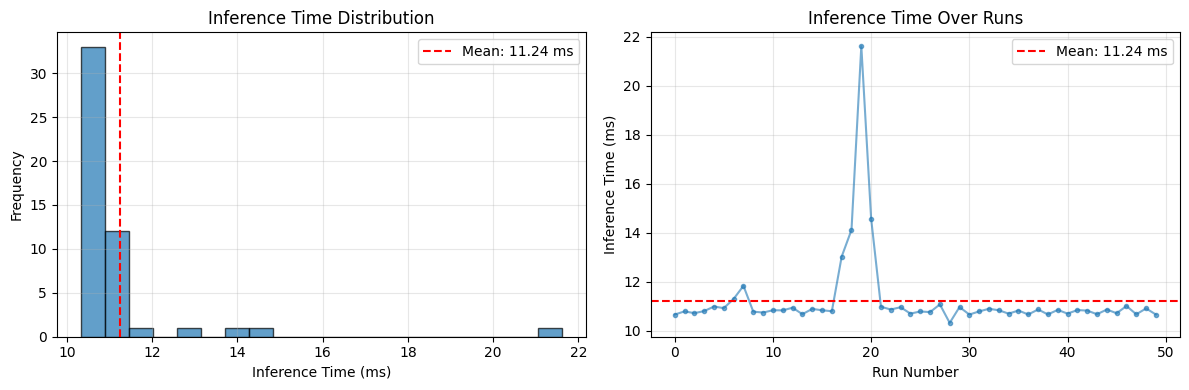

In [67]:
# Run benchmark
benchmark_times = benchmark_inference(
    model_path="../models/mobilenet_v2_xnnpack.pte",
    num_runs=50
)

### mobilenet_v2_quantized_xnnpack.pte

Benchmarking model: ../models/mobilenet_v2_quantized_xnnpack.pte
Number of runs: 50

Warming up...
Running benchmark...

BENCHMARK RESULTS
  Mean:   3.91 ms
  Median: 3.69 ms
  Std:    0.55 ms
  Min:    3.61 ms
  Max:    6.68 ms


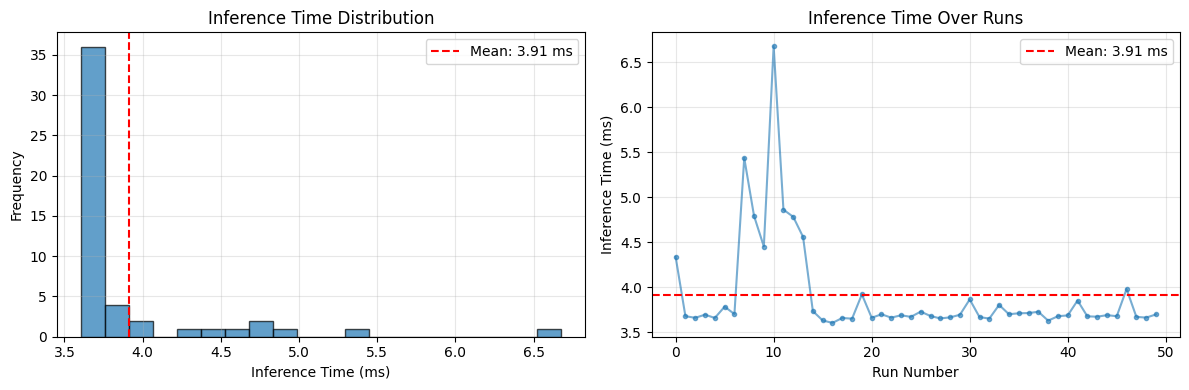

In [68]:
# Run benchmark
benchmark_times = benchmark_inference(
    model_path="../models/mobilenet_v2_quantized_xnnpack.pte",
    num_runs=50
)

## 13. Summary

In this notebook, we:

1. ✓ Set up the EXECUTORCH environment
2. ✓ Loaded and preprocessed images
3. ✓ Performed inference with EXECUTORCH models
4. ✓ Created reusable classification functions
5. ✓ Integrated with Raspberry Pi camera 
6. ✓ Benchmarked model performance

**Next Steps:**
- Export your own custom models
- Build real-time classification applications
- Optimize for your specific hardware

---

**Author:** Prof. Marcelo Rovai (UNIFEI University)

**Resources:**
- [EXECUTORCH Documentation](https://pytorch.org/executorch/)
- [PyTorch Mobile](https://pytorch.org/mobile/)
- [EdgeML Made Ease Book](https://mjrovai.github.io/EdgeML_Made_Ease_ebook/)